# Описательная статистика

## Модуль 3: Меры центральной тенденции, разброса и визуализация данных

В этом ноутбуке мы рассмотрим основные описательные статистики, которые позволяют кратко охарактеризовать набор данных.

### Содержание:
1. Меры центральной тенденции (среднее, медиана, мода)
2. Меры разброса (дисперсия, стандартное отклонение, IQR, размах)
3. Квантили и перцентили
4. Визуализация данных (гистограммы, box plots, violin plots)
5. Асимметрия и эксцесс

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('Библиотеки успешно загружены!')

Библиотеки успешно загружены!


## 1. Меры центральной тенденции

### 1.1 Среднее арифметическое (Mean)

$$\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i$$

**Свойства:**
- Чувствительно к выбросам
- $\sum_{i=1}^{n} (x_i - \bar{x}) = 0$
- Минимизирует $\sum_{i=1}^{n} (x_i - c)^2$

### 1.2 Медиана (Median)

$$\tilde{x} = \begin{cases} x_{(n+1)/2} & \text{если } n \text{ нечётное} \\ \frac{x_{n/2} + x_{n/2+1}}{2} & \text{если } n \text{ чётное} \end{cases}$$

**Свойства:**
- Устойчива к выбросам
- Разделяет данные на две равные половины

### 1.3 Мода (Mode)

Наиболее часто встречающееся значение.

**Сравнение:**
- Среднее > Медиана > Мода: правосторонняя асимметрия
- Среднее < Медиана < Мода: левосторонняя асимметрия
- Среднее = Медиана = Мода: симметричное распределение

Сравнение мер центральной тенденции

Без выбросов (n=100):
  Среднее: 48.96
  Медиана: 48.73
  Мода: 23.80

С выбросами (n=103):
  Среднее: 52.20
  Медиана: 49.28
  Мода: 23.80


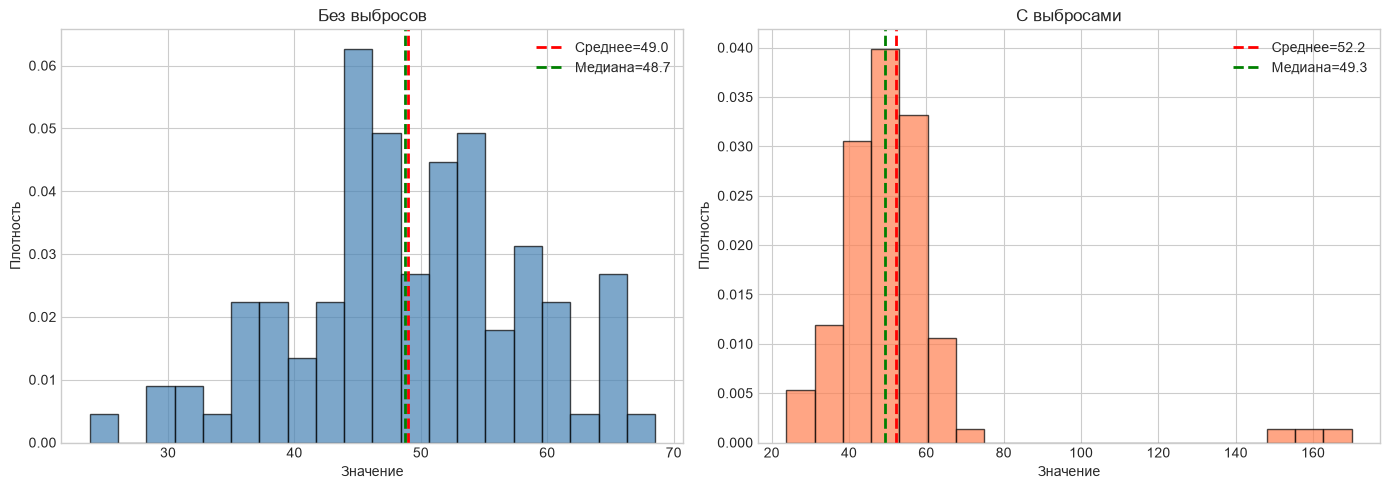


Вывод: Среднее чувствительно к выбросам, медиана - нет.


In [2]:
# Пример: Меры центральной тенденции
np.random.seed(42)

# Генерация данных с выбросами
data_normal = np.random.normal(50, 10, 100)
data_with_outliers = np.append(data_normal, [150, 160, 170])  # Добавляем выбросы

print('Сравнение мер центральной тенденции')
print('=' * 60)
print(f'\nБез выбросов (n={len(data_normal)}):')
print(f'  Среднее: {np.mean(data_normal):.2f}')
print(f'  Медиана: {np.median(data_normal):.2f}')
print(f'  Мода: {stats.mode(data_normal, keepdims=True).mode[0]:.2f}')

print(f'\nС выбросами (n={len(data_with_outliers)}):')
print(f'  Среднее: {np.mean(data_with_outliers):.2f}')
print(f'  Медиана: {np.median(data_with_outliers):.2f}')
print(f'  Мода: {stats.mode(data_with_outliers, keepdims=True).mode[0]:.2f}')

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Без выбросов
axes[0].hist(data_normal, bins=20, density=True, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(np.mean(data_normal), color='red', linestyle='--', linewidth=2, label=f'Среднее={np.mean(data_normal):.1f}')
axes[0].axvline(np.median(data_normal), color='green', linestyle='--', linewidth=2, label=f'Медиана={np.median(data_normal):.1f}')
axes[0].set_xlabel('Значение')
axes[0].set_ylabel('Плотность')
axes[0].set_title('Без выбросов')
axes[0].legend()

# С выбросами
axes[1].hist(data_with_outliers, bins=20, density=True, alpha=0.7, color='coral', edgecolor='black')
axes[1].axvline(np.mean(data_with_outliers), color='red', linestyle='--', linewidth=2, label=f'Среднее={np.mean(data_with_outliers):.1f}')
axes[1].axvline(np.median(data_with_outliers), color='green', linestyle='--', linewidth=2, label=f'Медиана={np.median(data_with_outliers):.1f}')
axes[1].set_xlabel('Значение')
axes[1].set_ylabel('Плотность')
axes[1].set_title('С выбросами')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nВывод: Среднее чувствительно к выбросам, медиана - нет.')

## 2. Меры разброса

### 2.1 Дисперсия (Variance)

**Выборочная дисперсия:**
$$s^2 = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2$$

**Генеральная дисперсия:**
$$\sigma^2 = \frac{1}{N} \sum_{i=1}^{N} (x_i - \mu)^2$$

### 2.2 Стандартное отклонение (Standard Deviation)
$$s = \sqrt{s^2}$$

### 2.3 Интерквартильный размах (IQR)
$$IQR = Q_3 - Q_1$$

### 2.4 Размах (Range)
$$R = x_{\max} - x_{\min}$$

### 2.5 Среднее абсолютное отклонение (MAD)
$$MAD = \frac{1}{n} \sum_{i=1}^{n} |x_i - \tilde{x}|$$

Меры разброса для разных выборок
Мера                             σ=5       σ=10       σ=20
----------------------------------------------------------------------
Дисперсия                      20.62      90.95     470.27
Стандартное отклонение          4.54       9.54      21.69
IQR                             5.03      13.44      27.20
Размах                         22.36      46.39     141.88
MAD                             3.59       7.52      16.97


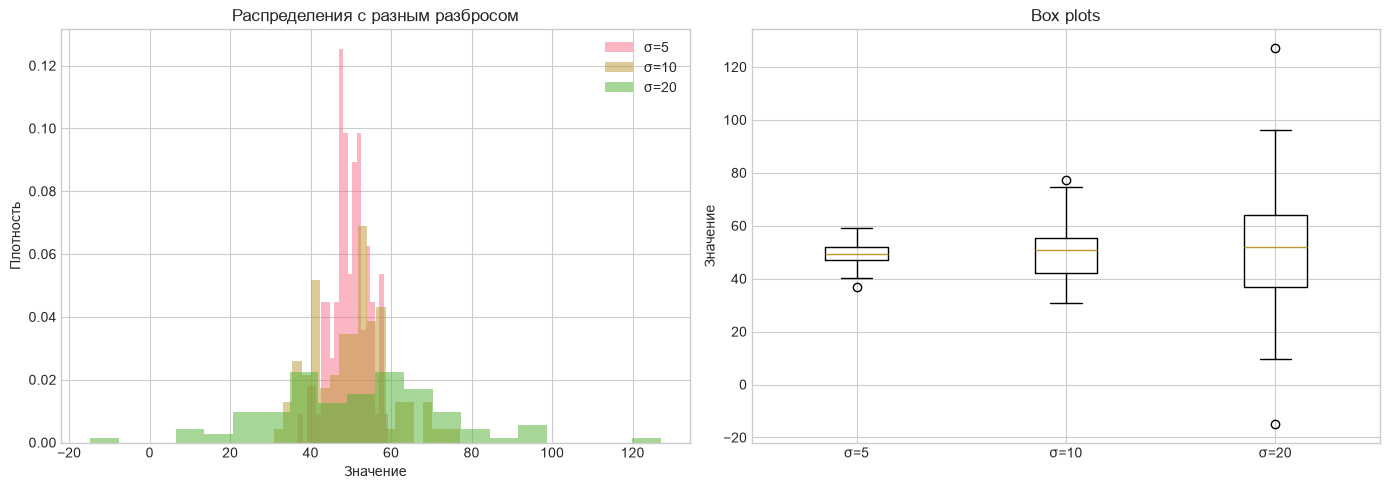

In [4]:
# Пример: Меры разброса
np.random.seed(42)

# Три выборки с разным разбросом
data1 = np.random.normal(50, 5, 100)   # Малый разброс
data2 = np.random.normal(50, 10, 100)  # Средний разброс
data3 = np.random.normal(50, 20, 100)  # Большой разброс

datasets = {'σ=5': data1, 'σ=10': data2, 'σ=20': data3}

print('Меры разброса для разных выборок')
print('=' * 70)
print(f'{"Мера":<25} {"σ=5":>10} {"σ=10":>10} {"σ=20":>10}')
print('-' * 70)

for name in ['Дисперсия', 'Стандартное отклонение', 'IQR', 'Размах', 'MAD']:
    values = []
    for data in datasets.values():
        if name == 'Дисперсия':
            values.append(np.var(data, ddof=1))
        elif name == 'Стандартное отклонение':
            values.append(np.std(data, ddof=1))
        elif name == 'IQR':
            values.append(np.percentile(data, 75) - np.percentile(data, 25))
        elif name == 'Размах':
            values.append(np.max(data) - np.min(data))
        elif name == 'MAD':
            values.append(np.mean(np.abs(data - np.median(data))))
    print(f'{name:<25} {values[0]:>10.2f} {values[1]:>10.2f} {values[2]:>10.2f}')

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограммы
for label, data in datasets.items():
    axes[0].hist(data, bins=20, density=True, alpha=0.5, label=label)
axes[0].set_xlabel('Значение')
axes[0].set_ylabel('Плотность')
axes[0].set_title('Распределения с разным разбросом')
axes[0].legend()
# Box plots
bp = axes[1].boxplot(datasets.values())
axes[1].set_xticklabels(datasets.keys())
axes[1].set_ylabel('Значение')
axes[1].set_title('Box plots')

plt.tight_layout()
plt.show()

## 3. Квантили и перцентили

**Перцентиль** — значение, ниже которого находится определённый процент наблюдений.

$p$-й перцентиль $x_p$ удовлетворяет: $P(X \leq x_p) = p/100$

**Квантили:**
- **Q1** (25-й перцентиль) — нижний квартиль
- **Q2** (50-й перцентиль) — медиана
- **Q3** (75-й перцентиль) — верхний квартиль

**IQR (Interquartile Range):**
$$IQR = Q_3 - Q_1$$

**Правило для выбросов (1.5×IQR):**
- Выброс: $x < Q_1 - 1.5 \times IQR$ или $x > Q_3 + 1.5 \times IQR$

Анализ квартилей
Q1 (25-й перцентиль): 89.50
Q2 (Медиана): 100.19
Q3 (75-й перцентиль): 109.55
IQR: 20.06

Границы для выбросов:
  Нижняя: 59.41
  Верхняя: 139.64

Количество выбросов: 4 (0.8%)


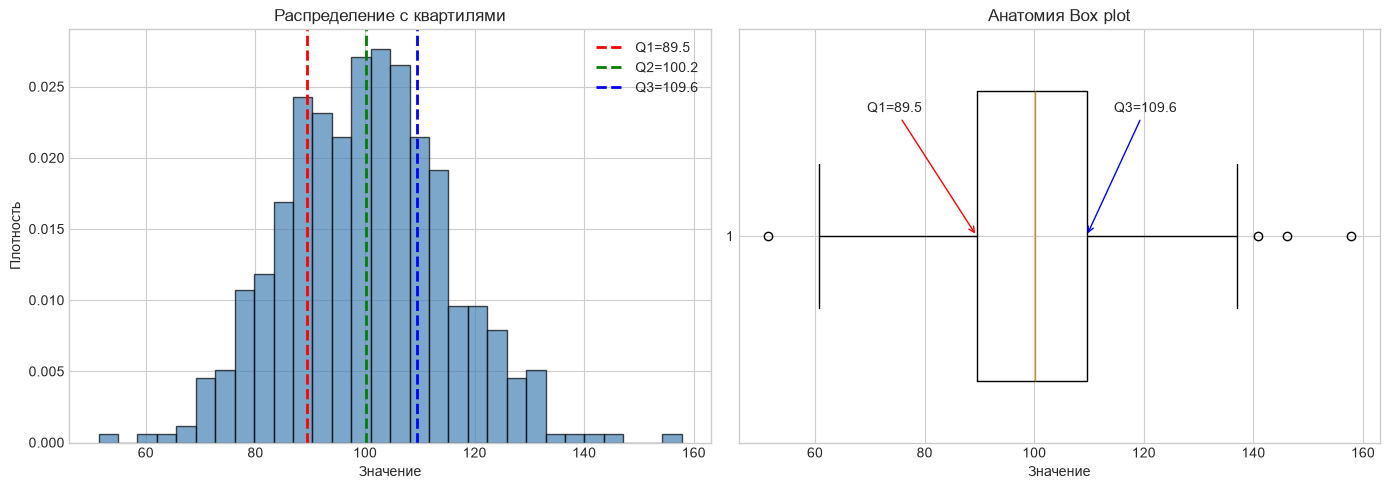

In [5]:
# Пример: Квантили и Box plot
np.random.seed(42)

data = np.random.normal(100, 15, 500)

# Вычисление квартилей
Q1 = np.percentile(data, 25)
Q2 = np.percentile(data, 50)  # Медиана
Q3 = np.percentile(data, 75)
IQR = Q3 - Q1

# Границы для выбросов
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Выбросы
outliers = data[(data < lower_bound) | (data > upper_bound)]

print('Анализ квартилей')
print('=' * 50)
print(f'Q1 (25-й перцентиль): {Q1:.2f}')
print(f'Q2 (Медиана): {Q2:.2f}')
print(f'Q3 (75-й перцентиль): {Q3:.2f}')
print(f'IQR: {IQR:.2f}')
print(f'\nГраницы для выбросов:')
print(f'  Нижняя: {lower_bound:.2f}')
print(f'  Верхняя: {upper_bound:.2f}')
print(f'\nКоличество выбросов: {len(outliers)} ({len(outliers)/len(data)*100:.1f}%)')

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма с квартилями
axes[0].hist(data, bins=30, density=True, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(Q1, color='red', linestyle='--', linewidth=2, label=f'Q1={Q1:.1f}')
axes[0].axvline(Q2, color='green', linestyle='--', linewidth=2, label=f'Q2={Q2:.1f}')
axes[0].axvline(Q3, color='blue', linestyle='--', linewidth=2, label=f'Q3={Q3:.1f}')
axes[0].set_xlabel('Значение')
axes[0].set_ylabel('Плотность')
axes[0].set_title('Распределение с квартилями')
axes[0].legend()

# Box plot с анатомией
bp = axes[1].boxplot(data, vert=False, widths=0.7)
axes[1].set_xlabel('Значение')
axes[1].set_title('Анатомия Box plot')

# Аннотации
axes[1].annotate(f'Q1={Q1:.1f}', xy=(Q1, 1), xytext=(Q1-20, 1.3),
                 arrowprops=dict(arrowstyle='->', color='red'))
axes[1].annotate(f'Q3={Q3:.1f}', xy=(Q3, 1), xytext=(Q3+5, 1.3),
                 arrowprops=dict(arrowstyle='->', color='blue'))

plt.tight_layout()
plt.show()

## 4. Визуализация данных

### Типы визуализаций:
1. **Гистограмма** — распределение одной переменной
2. **Box plot** — квартили и выбросы
3. **Violin plot** — плотность распределения
4. **Scatter plot** — связь между двумя переменными
5. **Heatmap** — корреляционная матрица

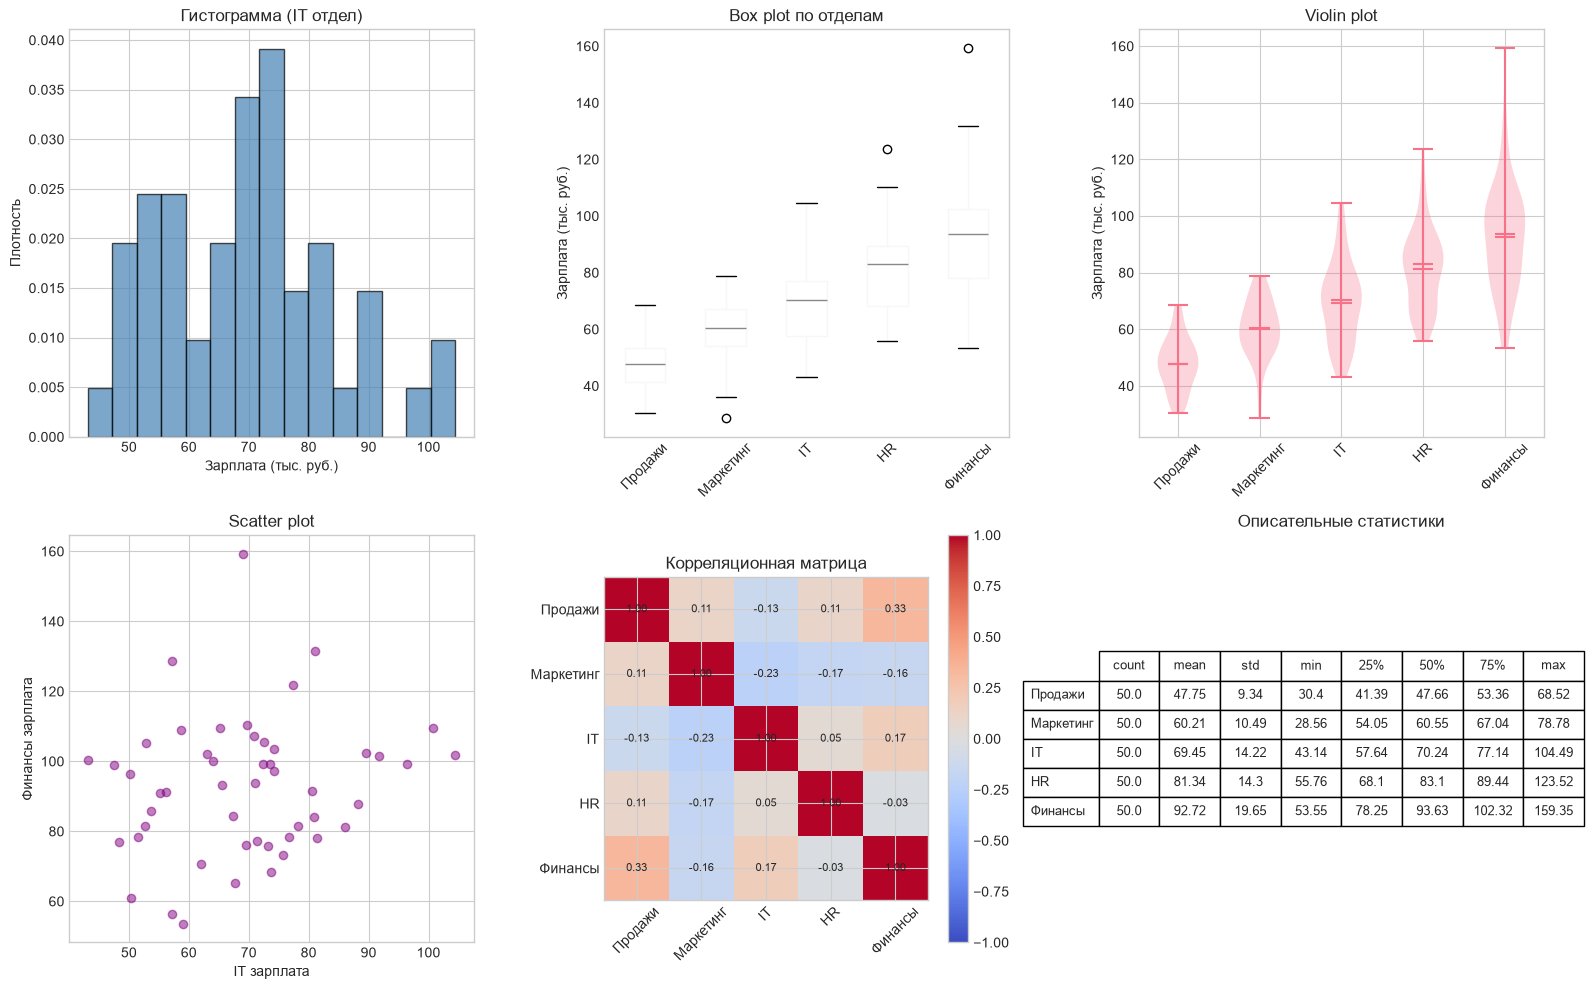

In [6]:
# Пример: Разные типы визуализаций
np.random.seed(42)

# Данные: зарплаты по отделам
departments = ['Продажи', 'Маркетинг', 'IT', 'HR', 'Финансы']
data = {
    dept: np.random.normal(50 + i*10, 10 + i*2, 50) 
    for i, dept in enumerate(departments)
}

df = pd.DataFrame(data)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Гистограмма
axes[0, 0].hist(df['IT'], bins=15, density=True, alpha=0.7, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Зарплата (тыс. руб.)')
axes[0, 0].set_ylabel('Плотность')
axes[0, 0].set_title('Гистограмма (IT отдел)')

# 2. Box plot
df.boxplot(ax=axes[0, 1], grid=False)
axes[0, 1].set_ylabel('Зарплата (тыс. руб.)')
axes[0, 1].set_title('Box plot по отделам')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Violin plot
parts = axes[0, 2].violinplot([df[dept] for dept in departments], showmeans=True, showmedians=True)
axes[0, 2].set_xticks(range(1, len(departments) + 1))
axes[0, 2].set_xticklabels(departments, rotation=45)
axes[0, 2].set_ylabel('Зарплата (тыс. руб.)')
axes[0, 2].set_title('Violin plot')

# 4. Scatter plot (два отдела)
axes[1, 0].scatter(df['IT'], df['Финансы'], alpha=0.5, color='purple')
axes[1, 0].set_xlabel('IT зарплата')
axes[1, 0].set_ylabel('Финансы зарплата')
axes[1, 0].set_title('Scatter plot')

# 5. Heatmap корреляций
corr_matrix = df.corr()
im = axes[1, 1].imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
axes[1, 1].set_xticks(range(len(departments)))
axes[1, 1].set_xticklabels(departments, rotation=45)
axes[1, 1].set_yticks(range(len(departments)))
axes[1, 1].set_yticklabels(departments)
axes[1, 1].set_title('Корреляционная матрица')
plt.colorbar(im, ax=axes[1, 1])

# Добавим значения корреляций
for i in range(len(departments)):
    for j in range(len(departments)):
        axes[1, 1].text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                       ha='center', va='center', fontsize=8)

# 6. Статистики
stats_df = df.describe().T
axes[1, 2].axis('off')
table = axes[1, 2].table(cellText=stats_df.round(2).values,
                         rowLabels=stats_df.index,
                         colLabels=stats_df.columns,
                         cellLoc='center',
                         loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)
axes[1, 2].set_title('Описательные статистики')

plt.tight_layout()
plt.show()

## 5. Асимметрия и эксцесс

### Асимметрия (Skewness)
Измеряет симметричность распределения.

$$\text{Skew} = \frac{\frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^3}{s^3}$$

- $\text{Skew} = 0$: симметричное распределение
- $\text{Skew} > 0$: правосторонняя асимметрия (длинный хвост справа)
- $\text{Skew} < 0$: левосторонняя асимметрия (длинный хвост слева)

### Эксцесс (Kurtosis)
Измеряет "остроконечность" распределения.

$$\text{Kurt} = \frac{\frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^4}{s^4} - 3$$

- $\text{Kurt} = 0$: нормальное распределение (мезокуртическое)
- $\text{Kurt} > 0$: остроконечное (лептокуртическое), тяжёлые хвосты
- $\text{Kurt} < 0$: плоское (платикуртическое), лёгкие хвосты

Асимметрия и эксцесс разных распределений
Распределение          Асимметрия    Эксцесс
------------------------------------------------------------
Нормальное                 0.1168     0.0662
Правостороннее             1.9808     5.3794
Левостороннее             -1.6354     3.0045
Тяжёлые хвосты            -0.1139     4.4027


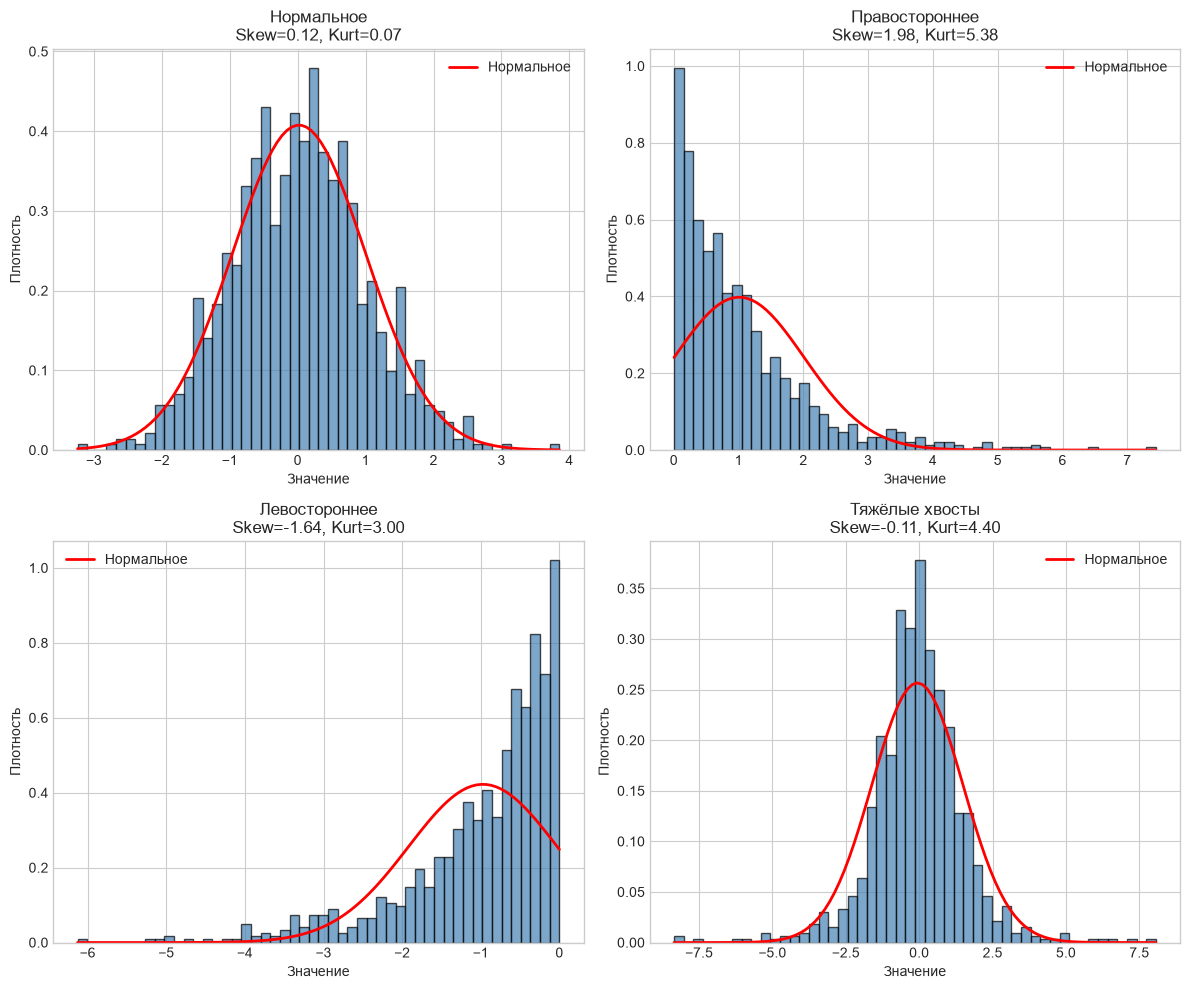

In [7]:
# Пример: Асимметрия и эксцесс
np.random.seed(42)

# Разные типы распределений
n = 1000
distributions = {
    'Нормальное': np.random.normal(0, 1, n),
    'Правостороннее': np.random.exponential(1, n),
    'Левостороннее': -np.random.exponential(1, n),
    'Тяжёлые хвосты': np.random.standard_t(3, n)
}

print('Асимметрия и эксцесс разных распределений')
print('=' * 60)
print(f'{"Распределение":<20} {"Асимметрия":>12} {"Эксцесс":>10}')
print('-' * 60)

for name, data in distributions.items():
    skew = stats.skew(data)
    kurt = stats.kurtosis(data)
    print(f'{name:<20} {skew:>12.4f} {kurt:>10.4f}')

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, (name, data) in enumerate(distributions.items()):
    ax = axes[idx // 2, idx % 2]
    ax.hist(data, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')
    
    # Добавим нормальную кривую для сравнения
    x_range = np.linspace(data.min(), data.max(), 100)
    ax.plot(x_range, stats.norm.pdf(x_range, np.mean(data), np.std(data)), 
            'r-', linewidth=2, label='Нормальное')
    
    ax.set_xlabel('Значение')
    ax.set_ylabel('Плотность')
    ax.set_title(f'{name}\nSkew={stats.skew(data):.2f}, Kurt={stats.kurtosis(data):.2f}')
    ax.legend()

plt.tight_layout()
plt.show()

## Упражнения

### Упражнение 1: Анализ данных о доходах
Даны данные о ежемесячных доходах (в тыс. руб.):
```
[35, 42, 45, 48, 50, 52, 55, 58, 60, 62, 65, 70, 75, 80, 150]
```

1. Вычислите среднее, медиану и моду
2. Вычислите дисперсию, стандартное отклонение и IQR
3. Есть ли выбросы? (правило 1.5×IQR)
4. Какая мера центральной тенденции лучше описывает эти данные?

### Упражнение 2: Сравнение групп
Даны две группы студентов:
- Группа A: [78, 82, 85, 88, 90, 92, 95, 96, 97, 98]
- Группа B: [60, 70, 75, 80, 85, 85, 90, 95, 100, 100]

1. Вычислите все описательные статистики для каждой группы
2. Какая группа более однородна?
3. Визуализируйте данные с помощью box plot

### Упражнение 3: Визуализация
Загрузите набор данных `iris` из seaborn и:
1. Постройте гистограммы для каждой характеристики
2. Постройте box plot по видам
3. Постройте корреляционную матрицу
4. Вычислите асимметрию и эксцесс

---

**Решения** можно найти в ноутбуке `solutions/05_Solutions.ipynb`